<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/7-algos-and-data-structures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithms & Data Structures

This class, *Algorithms & Data Structures*, introduces the most important computer science topics for machine learning, enabling you to design and deploy computationally efficient data models.

Through the measured exposition of theory paired with interactive examples, you’ll develop a working understanding of all of the essential data structures across the list, dictionary, tree, and graph families. You’ll also learn the key algorithms for working with these structures, including those for searching, sorting, hashing, and traversing data.

The content covered in this class is itself foundational for the *Optimization* class of the *Machine Learning Foundations* series.

Over the course of studying this topic, you'll:

* Use “Big O” notation to characterize the time efficiency and space efficiency of a given algorithm, enabling you to select or devise the most sensible approach for tackling a particular machine learning problem with the hardware resources available to you.
* Get acquainted with the entire range of the most widely-used Python data structures, including list-, dictionary-, tree-, and graph-based structures.
* Develop an understanding of all of the essential algorithms for working with data, including those for searching, sorting, hashing, and traversing.


**Note that this Jupyter notebook is not intended to stand alone. It is the companion code to a lecture or to videos from Jon Krohn's [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) series, which offer detail on the following:**

*Segment 1: Introduction to Data Structures and Algorithms*
* A Brief History of Data
* A Brief History of Algorithms
* “Big O” Notation for Time and Space Complexity

*Segment 2: Lists and Dictionaries*
* List-Based Data Structures: Arrays, Linked Lists, Stacks, Queues, and Deques
* Searching and Sorting: Binary, Bubble, Merge, and Quick
* Set-Based Data Structures: Maps and Dictionaries
* Hashing: Hash Tables, Load Factors, and Hash Maps

*Segment 3: Trees and Graphs*
* Trees: Decision Trees, Random Forests, and Gradient-Boosting (XGBoost)
* Graphs: Terminology, Directed Acyclic Graphs (DAGs)
* Resources for Further Study of Data Structures & Algorithms


# Segment 1: Intro to Data Structures & Algorithms

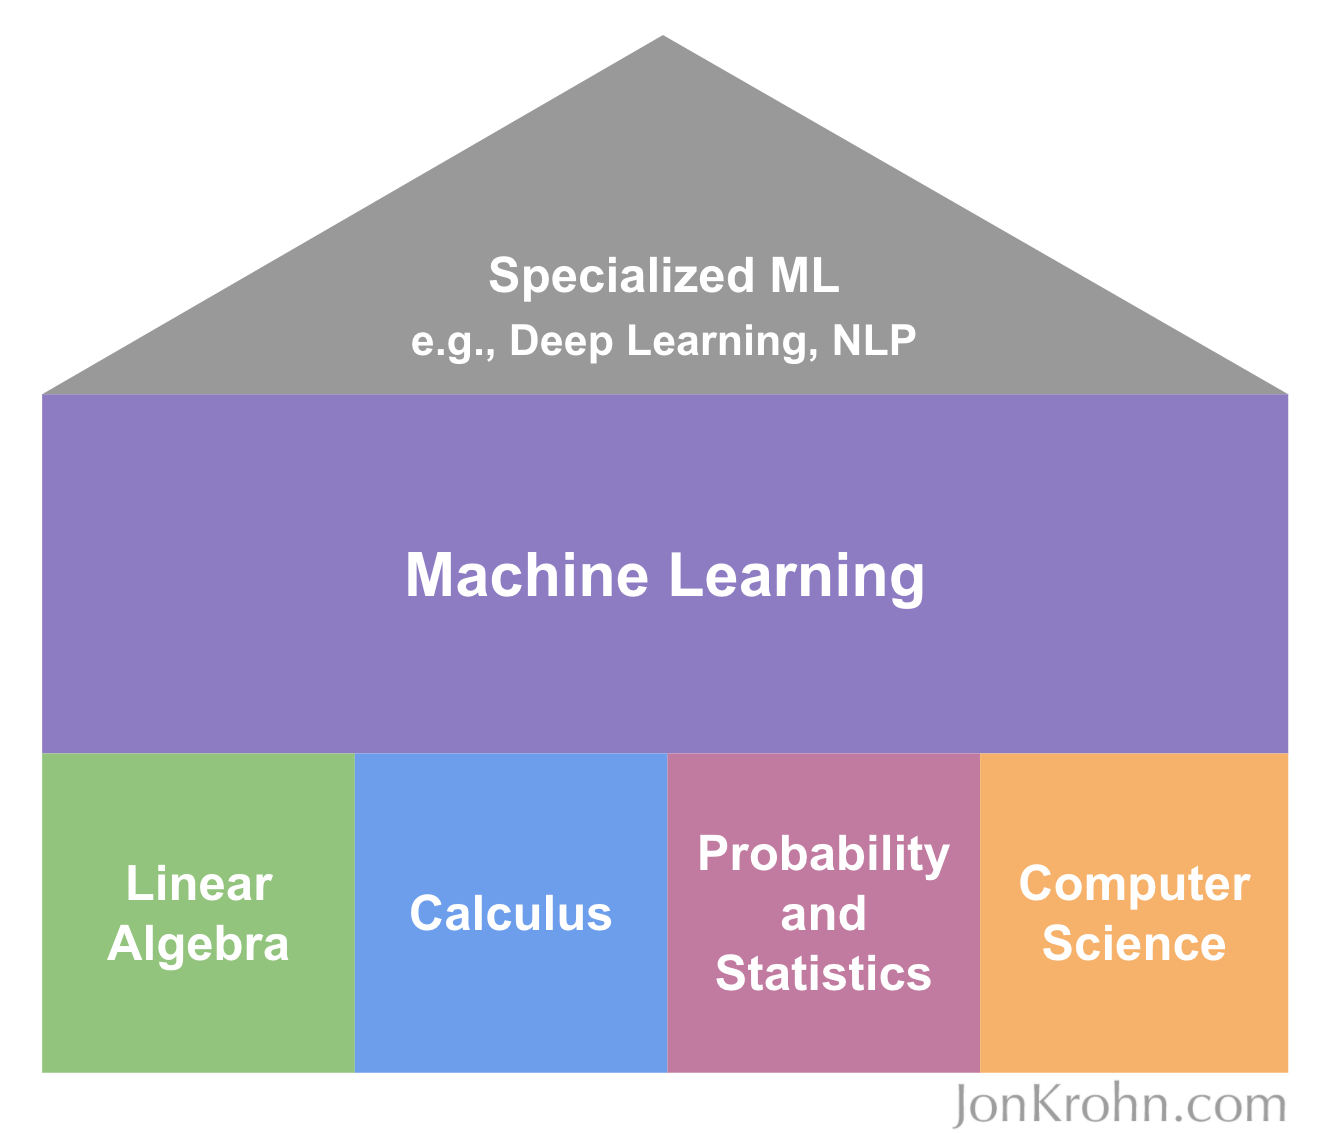

### Application of DSA to ML
Software 2.0: ML/DL algos typically have constant time/space complexity, assuming fixed batch size.
- Implementing ML models as graphs
  - Low level TensorFlow 
  - Low level PyTorch
  

### "Big O" Notation
- Constant runtime
- Linear runtime
- Polynomial runtime

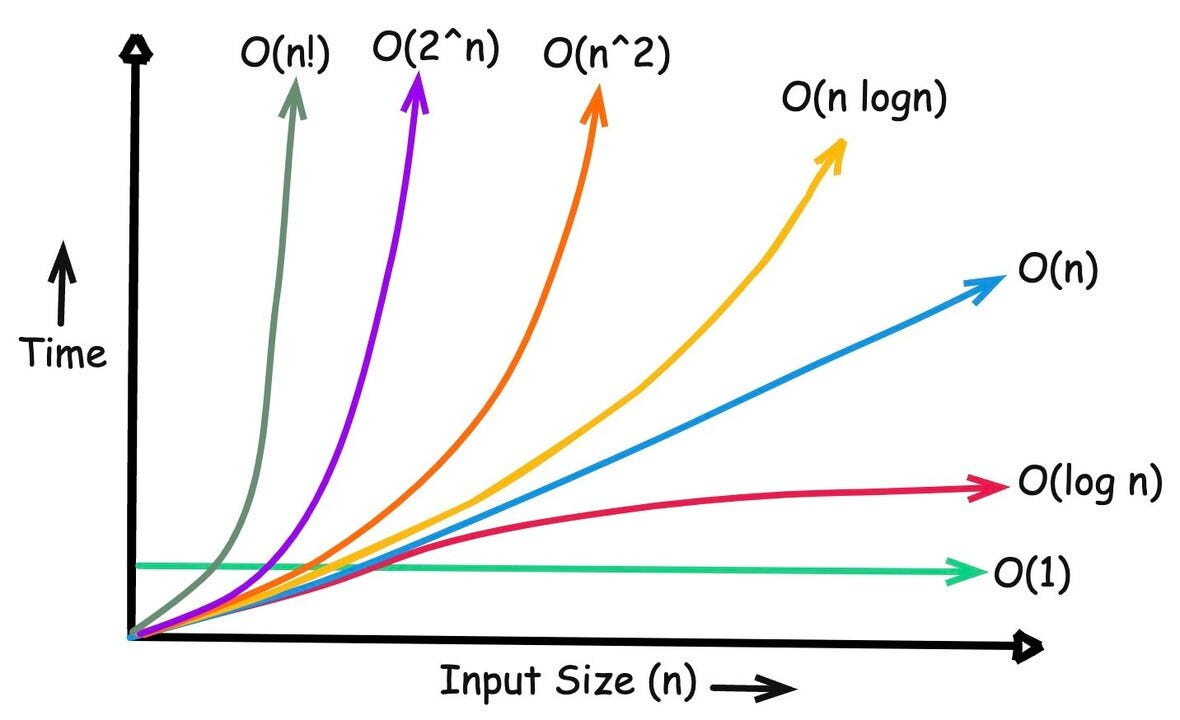

In [1]:
import numpy as np
# import tensorflow as tf # We will use PyTorch instead of TensorFlow for this project as tensorflow is not compatible with our current setup.
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time # for timing processes
import random # for generating random values

#### Constant Time

In [2]:
def take_first(my_list):
    return my_list[0]

In [3]:
short_list = [13, 25, 42]

In [4]:
tic = time.process_time() # if using a version of Python older than 3.3, you can use time.clock() here
first = take_first(short_list)
toc = time.process_time()

In [5]:
first

13

In [6]:
toc-tic

7.299999999954565e-05

In [7]:
long_list = [42] * 10**8 # one hundred million items

In [8]:
len(long_list)

100000000

In [9]:
tic = time.process_time()
first = take_first(long_list)
toc = time.process_time()

In [10]:
toc-tic

8.00000000005241e-05

In [11]:
list_lengths = [10**l for l in range(1, 8)]
list_lengths

[10, 100, 1000, 10000, 100000, 1000000, 10000000]

In [12]:
constant_times = []

for l in list_lengths:
    lst = [42]*l

    tic = time.process_time()
    x = take_first(lst)
    toc = time.process_time()

    constant_times.append(toc-tic)

In [13]:
constant_df = pd.DataFrame(list(zip(list_lengths, constant_times)), columns=['n', 'time'])
constant_df

,n,time
0,10,0.000013
1,100,0.000003
2,1000,0.000002
3,10000,0.000002
4,100000,0.000011
5,1000000,0.000350
6,10000000,0.000611


#### Linear Time

In [14]:
def find_max(my_list):
    max_value = my_list[0]
    for i in range(len(my_list)):
        if my_list[i] > max_value:
            max_value = my_list[i]
    return max_value

In [15]:
tic = time.process_time()
largest = find_max(short_list)
toc = time.process_time()

In [16]:
toc-tic

7.199999999940587e-05

In [17]:
largest

42

In [18]:
tic = time.process_time()
largest = find_max(long_list)
toc = time.process_time()

In [19]:
toc-tic

4.527778

In [20]:
largest

42

In [21]:
linear_times = []

for l in list_lengths:
    lst = [42]*l

    tic = time.process_time()
    x = find_max(lst)
    toc = time.process_time()

    linear_times.append(toc-tic)

In [22]:
linear_df = pd.DataFrame(list(zip(list_lengths, linear_times)), columns=['n', 'time'])
linear_df

,n,time
0,10,0.000494
1,100,0.000011
2,1000,0.000043
3,10000,0.000607
4,100000,0.005102
5,1000000,0.044019
6,10000000,0.427207


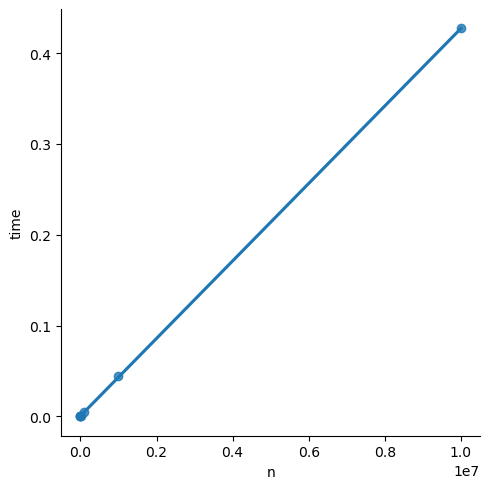

In [23]:
_ = sns.lmplot(x='n', y='time', data=linear_df, ci=None) # linear model (regression) plot

#### Polynomial Time

In [24]:
def element_multiplier(my_list):
    for i in range(len(my_list)):
        for j in range(len(my_list)):
            x = my_list[i] * my_list[j]

In [25]:
list_lengths

[10, 100, 1000, 10000, 100000, 1000000, 10000000]

In [26]:
list_lengths[:4] # compute time gets annoyingly long from list_lengths[5] onward

[10, 100, 1000, 10000]

In [27]:
granular_list_lengths = list_lengths[:4] + [50, 500, 5000]
granular_list_lengths.sort()
granular_list_lengths

[10, 50, 100, 500, 1000, 5000, 10000]

In [28]:
poly_times = []

for l in granular_list_lengths:
    lst = [42]*l

    tic = time.process_time()
    x = element_multiplier(lst)
    toc = time.process_time()

    poly_times.append(toc-tic)

In [29]:
poly_df = pd.DataFrame(list(zip(granular_list_lengths, poly_times)), columns=['n', 'time'])
poly_df

,n,time
0,10,0.000446
1,50,0.000440
2,100,0.000548
3,500,0.014836
4,1000,0.061002
5,5000,1.571280
6,10000,6.422714


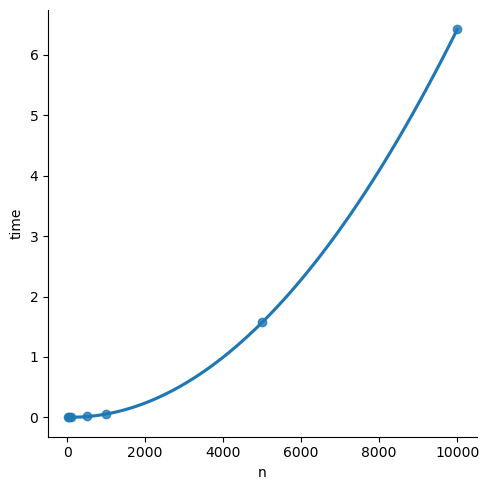

In [30]:
_ = sns.lmplot(x='n', y='time', data=poly_df, ci=None, order=2)

**In Big O notation**:

* Constant: O(1)
* Linear: O($n$)
* Polynomial: O($n^2$)

**Other common runtimes**:

* Logarithmic: O(log $n$)
* Exponential: O($2^n$)
* O($n$ log $n$)
* O($n!$)

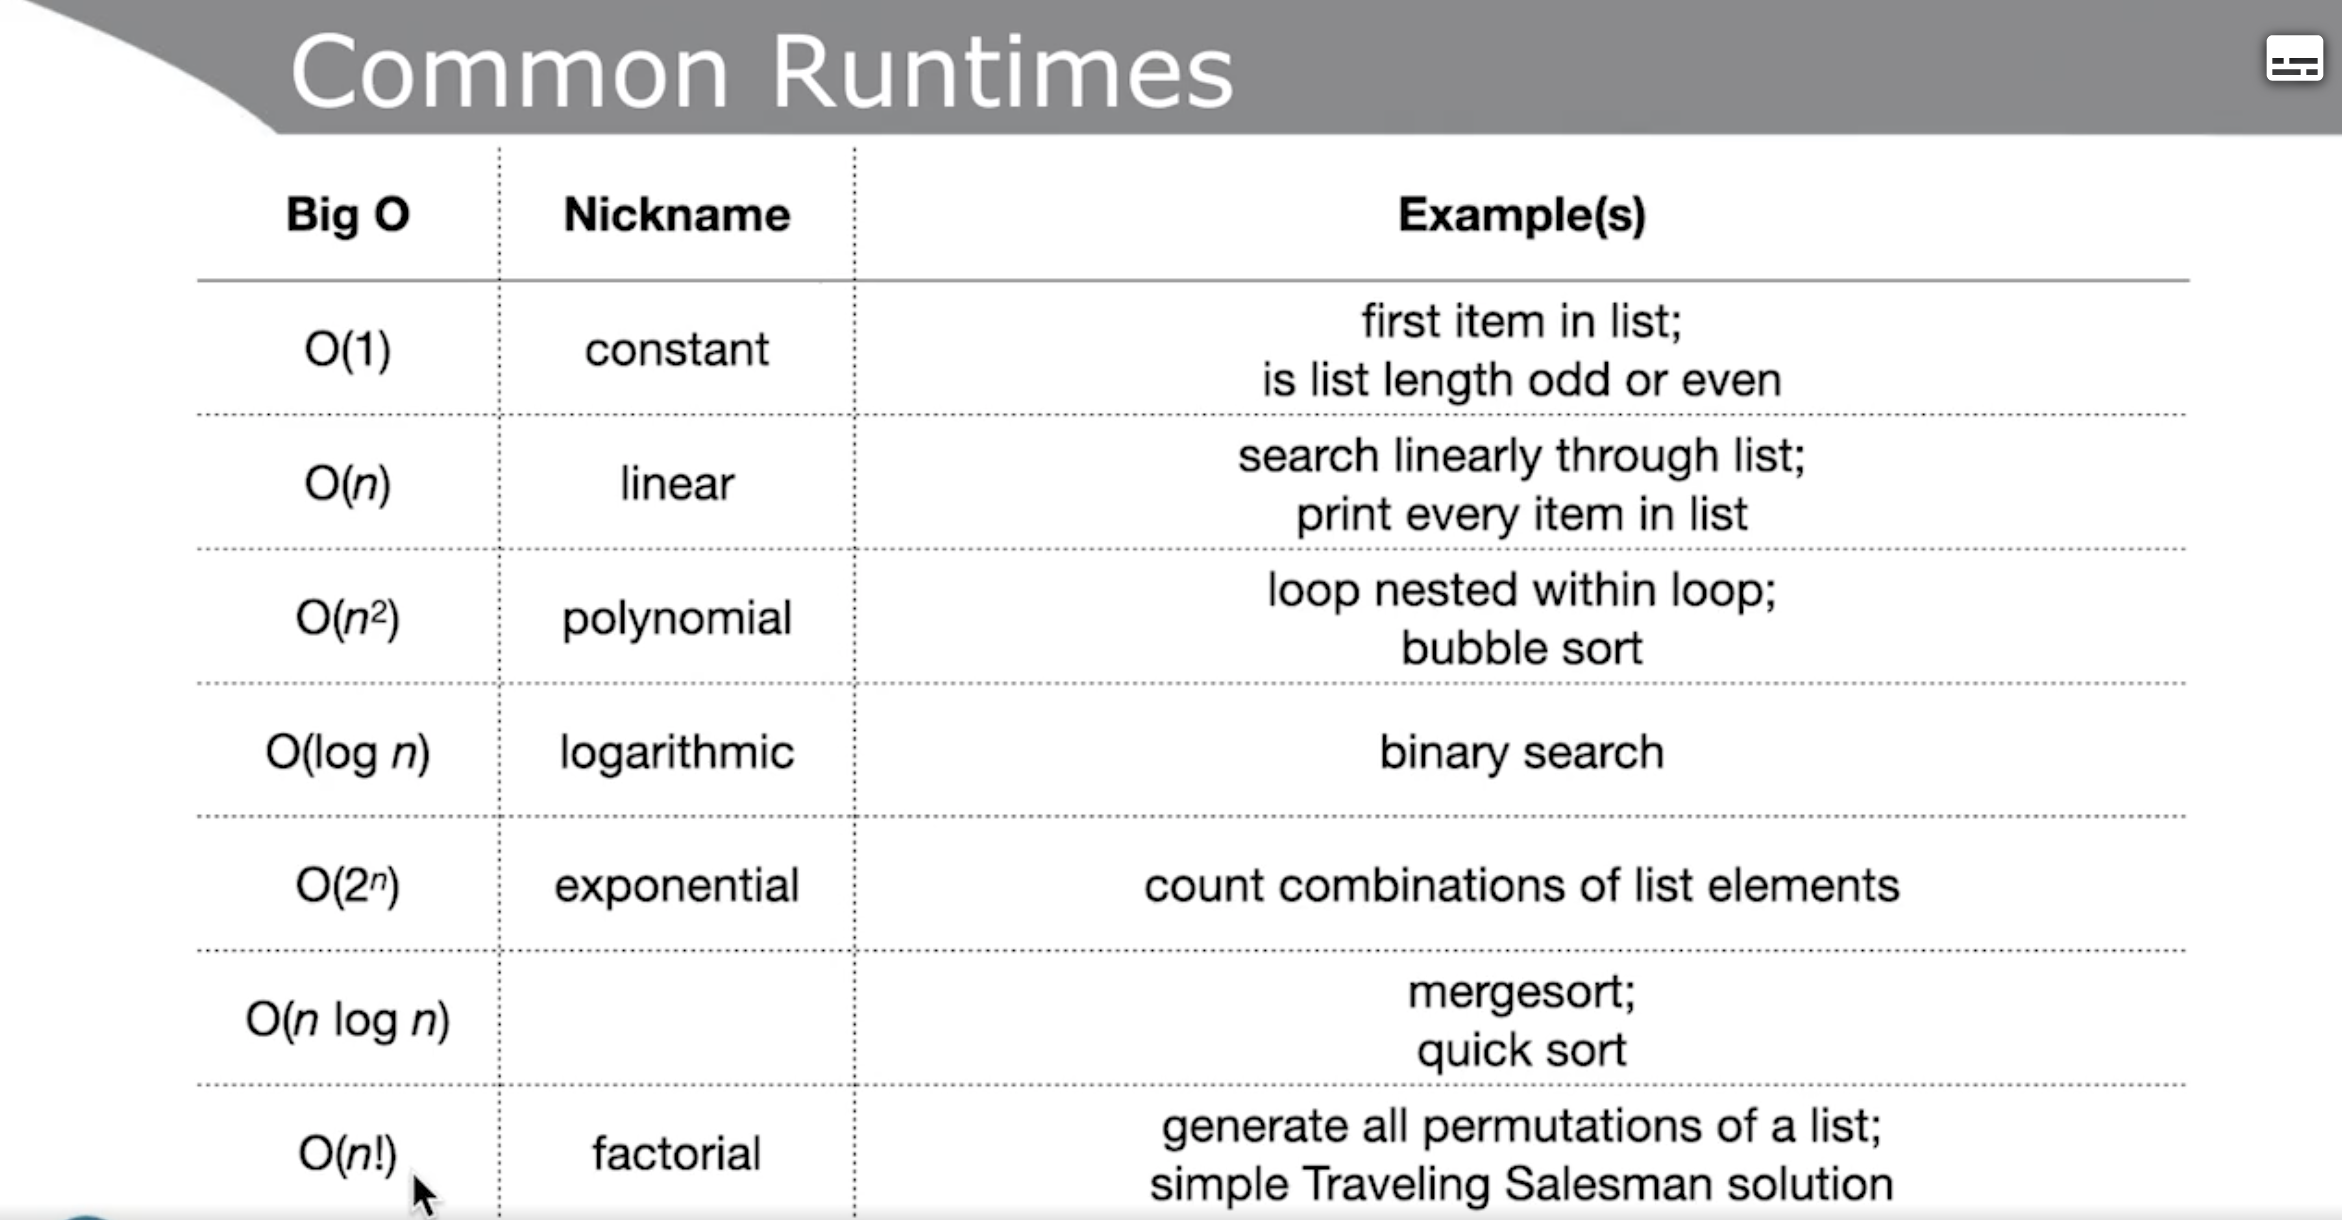

## Segment 2: Lists and Dictionaries

### List-Based Data Structures

#### Lists
An ordered collection of items which means we can get an item by its index

##### List based data structures
- arrays
- linked lists
- stacks
- queues
- deques

In [31]:
t = [25, 2, 5]
t

[25, 2, 5]

Lists in Python are **extensible** by default:

In [32]:
t.append(26)
t

[25, 2, 5, 26]

In [33]:
t[2]

5

Cannot apply mathematical operators, e.g., try uncommenting:

In [34]:
# t/2

#### Arrays
It is the type of list on which we can do mathematic operations to. 
- Used extensively in ML foundations and is the most important data structure, commonly used for:
  - Tensor which is the fundamental building block of ML (scalar to 3D tensor)
  - Holding data for training models. It doesn't need to be in jp notebook as np array. It can be an input from a file i.e HDF5, CSV
  - Used for preprocessing data
  - Receiving model outputs
  - calculate summary mattric
  - plotting

- All elements are of the same type (limitation)

In [35]:
x = np.array([25, 2, 5])
x

array([25,  2,  5])

In [36]:
x[2] # just like a list

np.int64(5)

In [37]:
x/2. # . mean floating 2 and not int 2

array([12.5,  1. ,  2.5])

In [38]:
y = torch.tensor([[25, 2, 5], [26, 1, 4]]) # we use tensor instead of numpy ?
y

tensor([[25,  2,  5],
        [26,  1,  4]])

In [39]:
y[0, 2]

tensor(5)

In [40]:
y/2.

tensor([[12.5000,  1.0000,  2.5000],
        [13.0000,  0.5000,  2.0000]])

In [41]:
z = tf.Variable([[[0, 1], [2, 3]], [[25, 26], [7, 9]]], dtype=tf.float16)
z

NameError: name 'tf' is not defined

In [ ]:
z[1, 0, 0]

<tf.Tensor: shape=(), dtype=float16, numpy=25.0>

In [ ]:
z/2.

<tf.Tensor: shape=(2, 2, 2), dtype=float16, numpy=
array([[[ 0. ,  0.5],
        [ 1. ,  1.5]],

       [[12.5, 13. ],
        [ 3.5,  4.5]]], dtype=float16)>

Arrays in Python are also typically extensible by default.

Note that it's very efficient (O(1)) to append items to end of list...

In [ ]:
np.append(x, 26)

array([25,  2,  5, 26])

...but time inefficient to add at start or middle of long list as later items will need to be shifted to later in list. Worst case is insert at beginning of list, which has O($n$) complexity.

Note that as well as appending, accessing an array element by index or finding the array's length are O(1).

#### Linked List
Similar to (vector) array, but elements aren't indexed.
Instead elements in the linked lists (called nodes or units) store which element in the list is next (nodes are linked).
- It makes adding or removing elements anywhere in the list computationally efficient (O(1)).
- Accessing elements is computationally inefficient (O(n)) in worst case.
- Not a built-in python DS
- Not common in ML

#### Doubly-Linked List
- Nodes stores both the next and the precedented element locations
- Same time-complexity to the linked list

#### Stacks
Can be implemented in Python with lists:
Link a deck of cards
- LIFO 
- Put (Push) into the stack
- Pop off of the stack
- Both pop and push are constant time complexity
- Rare to use directly to ML (direclty)
- Push and pop are O(1)

In [ ]:
s = []
s

[]

In [ ]:
s.append('five_of_diamonds') # push
s

['five_of_diamonds']

In [ ]:
s.append('queen_of_hearts')
s

['five_of_diamonds', 'queen_of_hearts']

In [ ]:
s.append('ace_of_spades')
s

['five_of_diamonds', 'queen_of_hearts', 'ace_of_spades']

In [ ]:
s.pop()

'ace_of_spades'

In [ ]:
s

['five_of_diamonds', 'queen_of_hearts']

#### Queues
- FIFO where stack was LIFO
- Head is the first/oldest element
- Tail is the last/newest element
- Enqueue
- Dequeue
- Peeking (just show)

#### Deques
- Double-ended queue
- We can enqueue or dequeue from either end
- See the DQN in jonkrohn.com/DQN (Deep Queue Learning Network) i.e only Deque(size=2000) where adding 2001st willl beckome 2000th

### Searching and Sorting
Algorithms that we can apply to the list

Topics in this section:
* Binary search
* Bubble sort
* Merge sort
* Quick sort

Time complexity, Space complexity and typical space/time tradeoff

Helpful for any ML pipelines i.e
  - Data capture
  - Preprocessor
  - Training
  - Deployment

#### Binary Search

Let's say we have an array, `b`:

In [ ]:
b = np.array([25, 2, 5, 14, 22, 11, 96, 1, 101])
b

array([ 25,   2,   5,  14,  22,  11,  96,   1, 101])

Under normal circumstances, the only way to search for a value (e.g., `25`) is to search element by element. In the worse-case, this has O($n$) time complexity (e.g., if we were to search `b` for `25` from its end).

If `b` already happens to be sorted, however...

In [ ]:
b.sort() # FYI: uses quick sort
b

array([  1,   2,   5,  11,  14,  22,  25,  96, 101])

...we can use the **binary search** algorithm, which has O(log $n$) time complexity:

* Start at the midpoint (`b` is nine elements long, so midpoint is 5th: `14`).
* Since `25` is larger than `14`, we need only search the top half of `b`...
* So we find the midpoint between the 5th element and the 9th, which is the 7th, and which happens to be `25`.
* Done! And in only two steps instead of seven (if we were to search elementwise from first onward).
* If we were searching for `22`, then our next search would be halfway between 5th and 7th elements, which is 6th element and voilà!
* With our nine-element array, worst case is four steps (for `1` or `101`) to find any value (or determine value *isn't* in array).

(Note: called *binary* because at each step we either search upward or downward.)

Doubling $n$ results in only one extra step in worst case:
* One step with array of length 1($= 2^0$)
* Two steps with length 2($= 2^1$) up to length 3
* Three steps with $n = 4 (= 2^2$) up to $n = 7$
* Four steps with $n = 8 (= 2^3$) up to $n = 15$
* Five steps with $n = 16 (= 2^4$) up to $n = 31$

Hence O(log $n$) where, as is typical in CS, we use $\text{log}_2$ (because of binary bits and frequently doubling/halving quantities). E.g.:

In [ ]:
np.log2(4) + 1

3.0

In [ ]:
np.log2(8) + 1

4.0

In [ ]:
np.log2(16) + 1

5.0

Recall that we retain only the dominant term, so O(log $n$ + 1) becomes O(log $n$).

Here's an implementation of binary search, for your reference, that *iterates* over binary search steps with a `while` loop:

In [ ]:
def binary_search(array, value):

    low = 0
    high = len(array)-1

    while low <= high:
        midpoint = (low + high) // 2 # rounds down to nearest integer after division
        if value < array[midpoint]:
            high = midpoint-1
        elif value > array[midpoint]:
            low = midpoint+1
        else:
            return midpoint
    return -1

In [ ]:
binary_search(b, 25)

6

In [ ]:
binary_search(b, 255)

-1

Alternatively, you could implement binary search with *recursion* instead of iteration:

In [ ]:
def recursive_binary_search(array, value, low, high):

    if low <= high:

        midpoint = (low + high) // 2

        if array[midpoint] == value:
            return midpoint
        elif array[midpoint] > value:
            return recursive_binary_search(array, value, low, midpoint-1)
        else:
            return recursive_binary_search(array, value, midpoint+1, high)
    else:
        return -1

In [ ]:
recursive_binary_search(b, 25, 0, len(b)-1)

6

In [ ]:
recursive_binary_search(b, 255, 0, len(b)-1)

-1

#### Bubble Sort

Binary search required a sorted list. To sort a list (e.g., from smallest to largest value), the most naïve (and computationally complex) approach would be to compare every given element with all other elements.

A common naïve implementation is the **bubble sort**, which allows the largest values to gradually "bubble up" toward the "top" (typically the end) of the array:

In [ ]:
def bubble_sort(array):

    n = len(array)

    for i in range(n-1):
        for j in range(0, n-1): # could be n-i-1 as, e.g., top value is guaranteed to have bubbled up in 1st iteration
            if array[j] > array[j+1]:
                array[j], array[j+1] = array[j+1], array[j]

    return array

In [ ]:
b = np.array([25, 2, 5, 14, 22, 11, 96, 1, 101])
b

array([ 25,   2,   5,  14,  22,  11,  96,   1, 101])

In [ ]:
bubble_sort(b)

array([  1,   2,   5,  11,  14,  22,  25,  96, 101])

* During each iteration, we make $n-1$ comparisons
* A total of $n-1$ iterations need to be made

$$ (n-1)(n-1) = n^2 -2n + 1 $$

Since we drop all terms but the dominant one, this leaves us with polynomial O($n^2$) time complexity for the worst case and the average case. (For more clever implementations, best case is O($n$) because array would already be sorted.)

In contrast, as is typical in algos, there is a time- vs memory-complexity trade-off: Memory complexity is constant, O(1).

In [ ]:
granular_list_lengths

[10, 50, 100, 500, 1000, 5000, 10000]

In [ ]:
max(granular_list_lengths)

10000

In [ ]:
random.sample(range(0, max(granular_list_lengths)), 5) # samples 5 integers w/o replacement from uniform distribution

[7906, 8845, 8249, 6160, 3448]

In [ ]:
bubble_times = []

for l in granular_list_lengths[0:7]:
    lst = random.sample(range(0, max(granular_list_lengths)), l)

    tic = time.process_time()
    x = bubble_sort(lst)
    toc = time.process_time()

    bubble_times.append(toc-tic)

In [ ]:
bubble_df = pd.DataFrame(list(zip(granular_list_lengths, bubble_times)), columns=['n', 'time'])
bubble_df

,n,time
0,10,0.000033
1,50,0.000578
2,100,0.002153
3,500,0.057291
4,1000,0.260174
5,5000,6.131653
6,10000,16.825840


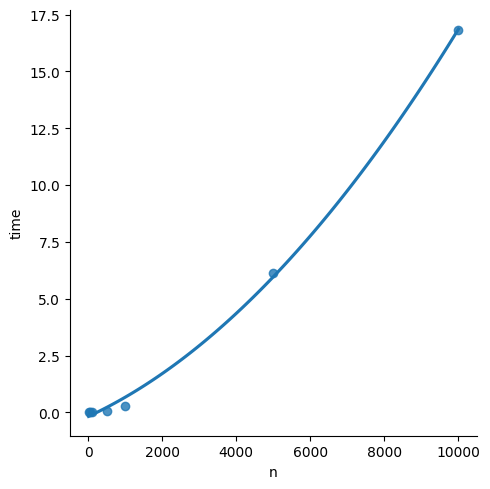

In [ ]:
_ = sns.lmplot(x='n', y='time', data=bubble_df, ci=None, order=2)

#### Merge Sort

* General idea is to "divide and conquer"; specifically:
    1. Halve the array into smaller arrays
    2. Sort the smaller arrays
    3. Merge them back into full array
* The above steps are carried out recursively so ultimately sort arrays of max length 2, then merge back up to full length.

In [ ]:
def merge_sort(my_list): # using list instead of array so we can .pop() (np arrays don't pop with built-in method)

    if len(my_list) > 1: # if length is 1, no need to sort (at deepest recursion, some will have len 1, others len 2)

        # 1. Halve:
        midpoint = len(my_list) // 2 # Note: This is ~O(log n) behavior
        left_half = my_list[:midpoint]
        right_half = my_list[midpoint:]

        # 2. Sort (recursively):
        left_half = merge_sort(left_half)
        right_half = merge_sort(right_half)

        my_list = []

        # 3. Merge:
        while len(left_half)>0 and len(right_half)>0: # Note: This inner loop exhibits ~O(n) behavior

            if left_half[0] < right_half[0]:
                my_list.append(left_half.pop(0)) # pop first element

            else: # 1st element of right half < 1st element of left
                my_list.append(right_half.pop(0))

        # If any elements remain from either half, they must be the largest value:
        for i in left_half:
            my_list.append(i)
        for i in right_half:
            my_list.append(i)

    return my_list

In [ ]:
m = [25, 2, 5, 14, 22, 11, 96, 1, 101]

In [ ]:
merge_sort(m)

[1, 2, 5, 11, 14, 22, 25, 96, 101]

Because of the O($n$) loop performing comparisons inside of the function halving list sizes (which we'll need to call O(log $n$) times), merge sort time complexity is the product, i.e., O($n$ log $n$).

In [ ]:
granular_list_lengths

[10, 50, 100, 500, 1000, 5000, 10000]

In [ ]:
ext_granular_lengths = granular_list_lengths + [50000, 100000] # extended
ext_granular_lengths

[10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

In [ ]:
merge_times = []

for l in ext_granular_lengths:
    lst = random.sample(range(0, max(ext_granular_lengths)), l)

    tic = time.process_time()
    x = merge_sort(lst)
    toc = time.process_time()

    merge_times.append(toc-tic)

In [ ]:
merge_df = pd.DataFrame(list(zip(ext_granular_lengths, merge_times)), columns=['n', 'time'])
merge_df

,n,time
0,10,0.015886
1,50,0.000112
2,100,0.000186
3,500,0.001134
4,1000,0.002419
5,5000,0.018492
6,10000,0.039816
7,50000,0.426445
8,100000,1.556839


On local laptop, $n=10000$ took ~0.05s with merge sort compared to ~10.5s with bubble sort: a ~200x speedup.

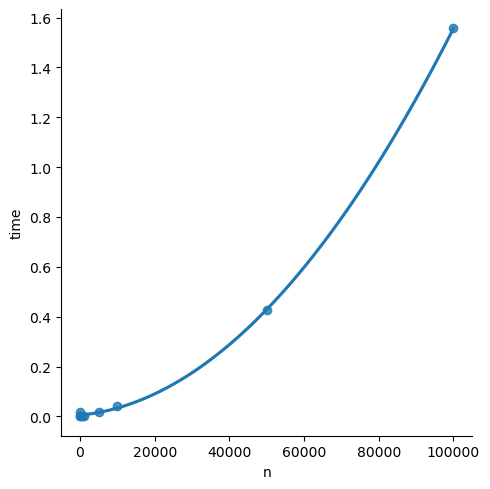

In [ ]:
_ = sns.lmplot(x='n', y='time', data=merge_df, ci=None, order=2)

In contrast, while memory complexity for bubble sort was O(1) because we were sorting "in place" (not storing any values in memory), memory complexity is O($n$) for merge sort.

(We need at least two array copies (2$n$) for the most space-efficient merge sort implementations, but we drop constants so this becomes O($n$). Our recursive merge sort implementation would require more as it stores several copies in memory; one more copy of size $n$ would be used for every time the array length doubles (log $n$) resulting in O($n$ log $n$) memory complexity.)

#### Quick Sort

Under many common conditions, the aptly-named **quick sort** is at least as time-efficient as merge sort while also being more space-efficient.

Like merge sort, quick sort uses the "divide and conquer" principle:
1. Pick a *pivot* point (often the final element, though it could be any element, e.g., first, random, median)
2. Move pivot within array such that all elements above pivot are larger (though randomly ordered) and all elements below pivot are smaller (though likewise randomly ordered)
    * Movement occurs element-by-element (and "in place", thus retaining O(1) memory complexity)
3. Recursively, perform quick sort both below and above pivot

NOTE: take the implementation from Grokking Algorithms codes

In [ ]:
def quick_sort(array):
    _quick_sort(array, 0, len(array)-1) # to start, low is index of first element in array; high is final element
    return array

In [ ]:
def _quick_sort(array, low, high):

    if low < high: # when low reaches high, we know all elements in array must be in order

        # Result of 2.: Element at "partitioning index" has been pivoted to its correct position
        p_index = partition(array, low, high)

        # 3. Recursively sort the elements below the partitioning index...
        _quick_sort(array, low, p_index-1)
        # ...and, separately, above the partitioning index:
        _quick_sort(array, p_index+1, high)

    return array

In [ ]:
def partition(array, low, high):

    # 1. Use the final element as the pivot:
    pivot = array[high]

    i = (low-1) # index of element on small side
    for j in range(low, high): # like a bubble swap, we compare pivot to all elements between low and high
        if array[j] < pivot: # if value < pivot, it's correctly on left so increment the smaller element's index...
            i = i+1
            array[i], array[j] = array[j], array[i]
    array[i+1], array[high] = array[high], array[i+1] # ...otherwise, swap greater value to right of pivot (now what we want)
    return(i+1) # return index of correctly positioned pivot

In [ ]:
b = np.array([25, 2, 5, 14, 22, 11, 96, 1, 101])

In [ ]:
quick_sort(b)

array([  1,   2,   5,  11,  14,  22,  25,  96, 101])

In [ ]:
list_lengths

[10, 100, 1000, 10000, 100000, 1000000, 10000000]

In [ ]:
list_lengths[:6]

[10, 100, 1000, 10000, 100000, 1000000]

In [ ]:
quick_times = []

for l in list_lengths[:6]:
    lst = random.sample(range(0, max(list_lengths[:6])), l)

    tic = time.process_time()
    x = quick_sort(lst)
    toc = time.process_time()

    quick_times.append(toc-tic)

In [ ]:
quick_df = pd.DataFrame(list(zip(list_lengths[:6], quick_times)), columns=['n', 'time'])
quick_df

,n,time
0,10,0.000019
1,100,0.000084
2,1000,0.001168
3,10000,0.019646
4,100000,0.267201
5,1000000,2.840130


At $n=$ 10k, about a 2x speed-up relative to merge sort (so ~400 relative to bubble sort).

At $n=$ 100k, about a 5x speed-up relative to merge sort.

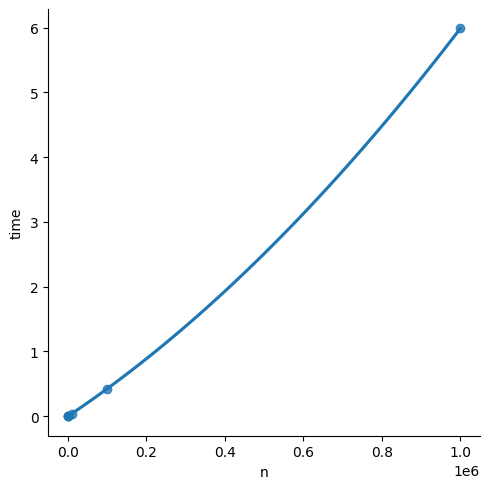

In [ ]:
_ = sns.lmplot(x='n', y='time', data=quick_df, ci=None, order=2)

**Average-case time**: The efficiency of quick sort comes from moving lower-valued pivots toward the front (ideally to the midpoint) of the array then "dividing and conquering" on either side of the pivot. In which case (the average case), quick sort behaves like a merge sort (thereby it has O($n$ log $n$) time complexity), but in a manner that requires only a single copy of the array in memory.

**Worst-case time**: With the pivot starting at the final element, if the array is already sorted, this is the worst case. There will be as many calls to `quick_sort()` as there are elements in the array (i.e., $n$ calls) and quick sort will perform a full round of bubble sorting (as per the `for j in range` loop) during each of those (i.e., $n-1$ comparisons); the product of these resulting in O($n^2$) time complexity. So, don't use quick sort if the array is nearly in order!

**Best-case time**: If all values in the array are equal, quick sort will scan over them all once to confirm this, in which case it has O($n$) time complexity. The more values that are equal in the array, the closer to O($n$) performance will be.

Those are the most frequently covered sorting algos. They're relatively straightforward to implement and illustrate time/space complexity trade-offs clearly. There are, however, many more ways to sort, with pros and cons related to time/space complexity as well as implementation difficulty. See the [Big O Cheat Sheet here](https://www.bigocheatsheet.com).

**Return to slides here.**

### Set-Based Data Structures: Maps/Dictionaries

In [ ]:
inventory = {}
inventory

{}

In [ ]:
inventory['hammer'] = [17]
inventory

{'hammer': [17]}

In [ ]:
inventory['nail'] = [2552]
inventory['unicorn'] = [2]
inventory['dolphin'] = ['none']

In [ ]:
inventory

{'hammer': [17], 'nail': [2552], 'unicorn': [2], 'dolphin': ['none']}

In [ ]:
inventory['dolphin'] = [0]
inventory

{'hammer': [17], 'nail': [2552], 'unicorn': [2], 'dolphin': [0]}

In [ ]:
inventory['unicorn'].append(3)
inventory

{'hammer': [17], 'nail': [2552], 'unicorn': [2, 3], 'dolphin': [0]}

**Return to slides here.**

### Hashing

Hash functions enable set searching in constant time, O(1). In contrast, list searching is linear time O(n) or O(logn) with binary search on pre-ordered list. The trick is that indexed data structures have O(1) time search/retrieval.
A hash function takes an input value and output a hash value. This hash values are used as indices of the hash table.

Let's say we have some value:

In [ ]:
value = 5551234567 # a phone number from any American '90s sitcom

A common hash function approach is to use the modulo operator on the last few digits of the value...

In [ ]:
split_value = [digit for digit in str(value)]
split_value

['5', '5', '5', '1', '2', '3', '4', '5', '6', '7']

In [ ]:
final_digits = int(''.join(split_value[-2:])) # final digits typically used b/c they tend to vary more than first ones
final_digits

67

In [ ]:
hash_value = final_digits % 10 # 10 is arbitrary, but would be used consistently across values to be hashed
hash_value

7

In [ ]:
def simple_hash(v):
    split_v = [digit for digit in str(v)]
    final_2 = int(''.join(split_v[-2:]))
    return final_2 % 10

In [ ]:
simple_hash(value)

7

In [ ]:
simple_hash(5557654321)

1

These hash values (`7` and `1`) could be used in a sequential, small-integer index, i.e., a *hash table*.

#### Collisions

Major problem with the `simple_hash()` function:
* The hash table has at most ten indices
* Ergo, many input values will result in **collisions**, e.g.:

In [ ]:
simple_hash(555)

5

In [ ]:
simple_hash(125)

5

Three common ways to resolve collisions:
1. Change the modulus denominator (e.g., `10` --> `11`); this adds procedural (and thus time) complexity to hash algo
2. Change the hash function entirely; ditto w.r.t. procedural complexity
3. Store a list (or similar) at the index, e.g.:

In [ ]:
hash_table = {}

In [ ]:
hash_table[simple_hash(555)] = [555]
hash_table

{5: [555]}

In [ ]:
hash_table[simple_hash(125)].append(125)
hash_table

{5: [555, 125]}

Such a list is called a **bucket**.

Worst case:
* All of the values hash to the same hash value (e.g., `5`)
* Thus, all of the values are stored in a single bucket
* Searching through the bucket has linear O($n$) time complexity

Alternatively, we can increase memory complexity instead of time complexity:
* Use very large modulus denominator
* Reduces probability of collisions
* If use denominator of `1e9`, we have a hash table with a billion buckets

Could also have a second hash function *inside* of the bucket (e.g., if we know we'll have a few very large buckets).

There is no "perfect hash". It depends on the values you're working with. There are many options to consider with various trade-offs.

**Load Factor**

Metric that guides hashing decisions:
$$ \text{load factor} = \frac{n_\text{values}}{n_\text{buckets}} $$

In [ ]:
10/1e9

1e-08

If we have ten values to store, but a billion buckets...
$$ \text{load factor} = \frac{10}{10^9} = 10^{-8}$$

...we are probably using much more memory than we need to. This is the case whenever load factor $\approx 0$.

As a general rule of thumb, the "Goldilocks" sweet spot would be to maintain a load factor between 0.6 and 0.75, providing a balance between memory and time complexity.

Below 0.6, you're potentially wasting memory with too many empty buckets.

Above 0.75, you risk having too many collisions, which degrades performance.

#### Hash Maps

In all of the above examples, we were hashing "values", but these "values" could in fact be the *keys* of a key-value pair, allowing us to have a **hash map**.

Let's say `Jane Dough` has receipt number `5551234567`, where we're using the receipt numbers as keys to look up customers.

We can add this as an entry in a hash table for quick lookup later (once we have many more receipts...):

In [ ]:
hash_map = {}

In [ ]:
hash_map[simple_hash(5551234567)] = [(5551234567, 'Jane Dough')]
hash_map

{7: [(5551234567, 'Jane Dough')]}

In [ ]:
hash_map[simple_hash(5551234568)] = [(5551234568, 'Johnny Dochevski')]
hash_map

{7: [(5551234567, 'Jane Dough')], 8: [(5551234568, 'Johnny Dochevski')]}

In [ ]:
hash_map[simple_hash(5551234578)].append((5551234578, 'Jon Krohn'))
hash_map

{7: [(5551234567, 'Jane Dough')],
 8: [(5551234568, 'Johnny Dochevski'), (5551234578, 'Jon Krohn')]}

**FYI**: In Python, dictionaries are hash maps.

#### String Keys

If our keys are character strings, we can still make use of hashing by converting the character string into an integer.

For example, we could use the [ASCII table](http://www.asciitable.com) to convert `Jon` to `112157156`.

**Exercises**

1. Use the `simple_hash()` function to add a customer named Jean d'Eau, who has receipt number `5551234569`, to `hash_map`.

1. You have a hash table with a million buckets and two million values to store in the table. What is your load factor? Are collisions likely? If so, how can the probability of collisions be reduced?

1. Use the octal standard of the ASCII table to convert the string `Llama` into an integer representation.

**Return to slides here.**

## Segment 3: Trees and Graphs

Trees are extension of linked list. It start at root node and add branch nodes. 
- All nodes must be connected
- Each child node has a parent node
- Childless node: Leaf or external
- No cyclic connection
- Tree's height = n-levels - 1 (for the root node)

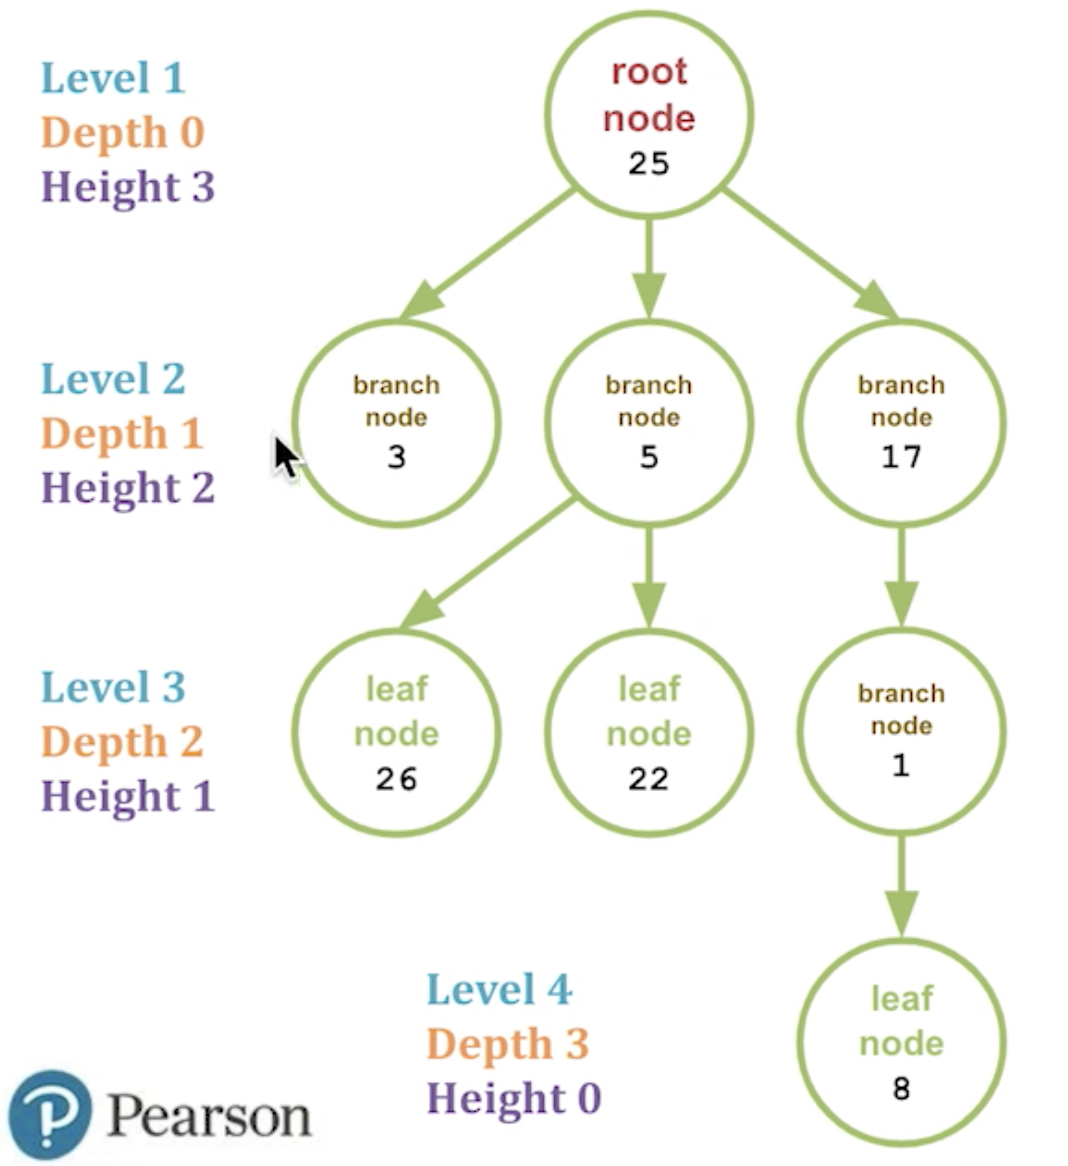

### Decision Trees

They are a binary tree (max 2 childs per parent node).
Types:
- Classification tree which predicts a categorical outcome i.e gender
- Regression Tree predicts continuous outcome i.e price of a house

In [43]:
titanic = sns.load_dataset('titanic')

In [44]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [45]:
np.unique(titanic['survived'], return_counts=True)

(array([0, 1]), array([549, 342]))

In [46]:
np.unique(titanic['sex'], return_counts=True)

(array(['female', 'male'], dtype=object), array([314, 577]))

In [47]:
np.unique(titanic['class'], return_counts=True)

(array(['First', 'Second', 'Third'], dtype=object), array([216, 184, 491]))

In [48]:
gender = pd.get_dummies(titanic['sex'])
gender

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
886,False,True
887,True,False
888,True,False
889,False,True


In [49]:
clas = pd.get_dummies(titanic['class'])
clas

,First,Second,Third
0,False,False,True
1,True,False,False
2,False,False,True
3,True,False,False
4,False,False,True
...,...,...,...
886,False,True,False
887,True,False,False
888,False,False,True
889,True,False,False


In [51]:
y = titanic.survived

In [52]:
X = pd.concat([clas.First, clas.Second, gender.female], axis=1) # axis-1 means we are concatenating columns (not rows)
X

,First,Second,female
0,False,False,False
1,True,False,True
2,False,False,True
3,True,False,True
4,False,False,False
...,...,...,...
886,False,True,False
887,True,False,True
888,False,False,True
889,True,False,False


In [86]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [56]:
X_train.shape

(596, 3)

In [57]:
y_train.shape

(596,)

In [58]:
X_test.shape

(295, 3)

In [59]:
y_test.shape

(295,)

In [60]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [61]:
dt_model = DecisionTreeClassifier()

In [ ]:
dt_model.fit(X_train, y_train) # Fit the decision tree model to the training data

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5555555555555556, 0.875, 'x[2] <= 0.5\ngini = 0.467\nsamples = 596\nvalue = [374, 222]'),
 Text(0.3333333333333333, 0.625, 'x[0] <= 0.5\ngini = 0.304\nsamples = 390\nvalue = [317, 73]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[1] <= 0.5\ngini = 0.263\nsamples = 314\nvalue = [265, 49]'),
 Text(0.1111111111111111, 0.125, 'gini = 0.252\nsamples = 237\nvalue = [202, 35]'),
 Text(0.3333333333333333, 0.125, 'gini = 0.298\nsamples = 77\nvalue = [63.0, 14.0]'),
 Text(0.4444444444444444, 0.375, 'gini = 0.432\nsamples = 76\nvalue = [52, 24]'),
 Text(0.7777777777777778, 0.625, 'x[0] <= 0.5\ngini = 0.4\nsamples = 206\nvalue = [57, 149]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'x[1] <= 0.5\ngini = 0.465\nsamples = 147\nvalue = [54, 93]'),
 Text(0.5555555555555556, 0.125, 'gini = 0.498\nsamples = 99\nvalue = [53, 46]'),
 Text(0.7777777777777778, 0.125, 'gini = 0.041\nsamples = 48\nvalue = [1, 47]'),
 Text(0.8888888

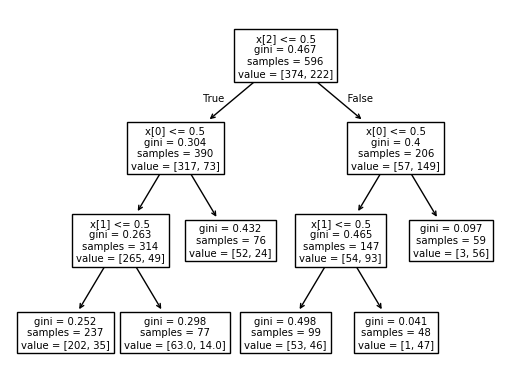

In [63]:
plot_tree(dt_model) # can read about Gini here: en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity

In [64]:
rose = pd.DataFrame([[1, 0, 1]], columns=X.columns) # must be matrix format
jack = pd.DataFrame([[0, 0, 0]], columns=X.columns)

In [66]:
dt_model.predict(rose)

array([1])

In [67]:
dt_model.predict_proba(rose)

array([[0.05084746, 0.94915254]])

In [69]:
dt_model.predict(jack)

array([0])

In [70]:
dt_model.predict_proba(jack)

array([[0.85232068, 0.14767932]])

In [72]:
dt_yhat = dt_model.predict(X_test) # decision trees are prone to overfitting training data

In [73]:
dt_yhat[0:6]

array([0, 0, 0, 1, 0, 1])

In [74]:
y_test[0:6]

709    1
439    0
840    0
720    1
39     1
290    1
Name: survived, dtype: int64

In [81]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [78]:
accuracy_score(y_test, dt_yhat)

0.7728813559322034

In [ ]:
roc_auc_score(y_test, dt_yhat) # Calculate the ROC (Receiver Operating Characteristic) AUC (Area Under the Curve) score for the decision tree predictions

0.7273809523809524

**Exercises**:

1. Create more features ([here are some ideas for creating them](https://towardsdatascience.com/predicting-the-survival-of-titanic-passengers-30870ccc7e8)) with an eye to improving model fit on the test data.

2. Re-train the decision tree on the training data and evaluate its accuracy and ROC AUC on the test data. How does the tree compare with an ordinary-least-squares regression model (from [*Intro to Stats*](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/6-statistics.ipynb)) trained on the same data?

**Return to slides here.**

### Random Forests

                        TRAINING DATA
                             |
              ┌──────────────┼──────────────┐
              ↓              ↓              ↓
        random sample   random sample   random sample
              ↓              ↓              ↓
           Tree 1          Tree 2          Tree 3
              ↓              ↓              ↓
          survive          died          survive
              \              |              /
               \             |             /
                └────── majority vote ────┘
                           ↓
                       SURVIVE

| Decision Tree                              | Random Forest                        |
| ------------------------------------------ | ------------------------------------ |
| One tree                                   | Many trees                           |
| Easy to visualize                          | Hard to visualize as a whole         |
| Very interpretable                         | Less interpretable                   |
| Can overfit easily                         | Much less prone to overfitting       |
| Can change a lot if data changes slightly  | More stable                          |
| One prediction                             | Trees vote                           |
| Uses all candidate features when splitting | Random subset of features considered |
| Trained on the training dataset            | Each tree gets a bootstrap sample    |


In [88]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


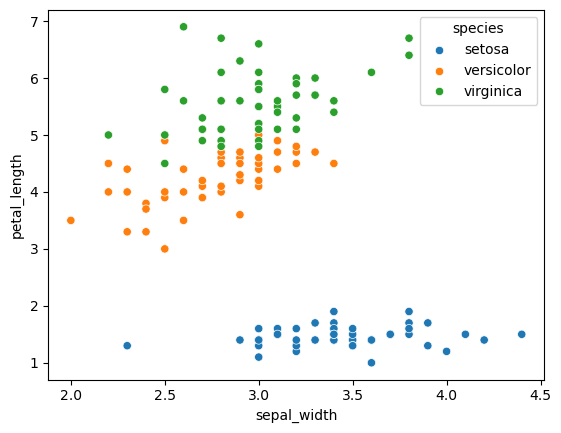

In [89]:
_ = sns.scatterplot(x='sepal_width', y='petal_length', hue='species', data=iris)

In [90]:
X = iris[['sepal_width', 'petal_length']]

In [91]:
y = iris.species

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [93]:
iris_dt = DecisionTreeClassifier().fit(X_train, y_train)

In [94]:
iris_dt_yhat = iris_dt.predict(X_test)

In [95]:
accuracy_score(iris_dt_yhat, y_test) # ROC AUC is for binary classifier

0.9

In [96]:
from sklearn.ensemble import RandomForestClassifier

In [97]:
rf_model = RandomForestClassifier(n_estimators=100) # n decision trees in forest

In [98]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [99]:
rf_yhat = rf_model.predict(X_test)

In [100]:
accuracy_score(rf_yhat, y_test)

0.96

**Return to slides.**

### Gradient-Boosted Trees

Random Forest builds many trees independently and lets them vote.
Gradient Boosting builds trees sequentially, where each new tree tries to correct the mistakes made so far.

```Tree 1
   ↓
look at its mistakes
   ↓
Tree 2 tries to correct them
   ↓
look at remaining mistakes
   ↓
Tree 3 tries to correct them
   ↓
...
   ↓
combine all corrections

In [ ]:
# pip install xgboost # Install the XGBoost library for gradient boosting algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 1.6 MB/s  0:00:01 eta 0:00:010m
Note: you may need to restart the kernel to use updated packages.


In [105]:
import xgboost as xgb

XGBoost `DMatrix()` method requires numeric inputs, not strings:

In [104]:
y_train[0:6]

96     versicolor
105     virginica
66     versicolor
0          setosa
122     virginica
67     versicolor
Name: species, dtype: str

In [112]:
mapping = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
y_train_int = y_train.map(mapping)
y_test_int = y_test.map(mapping)

In [113]:
y_train_int[0:6]

96     1
105    2
66     1
0      0
122    2
67     1
Name: species, dtype: int64

In [ ]:
D_train = xgb.DMatrix(X_train, label=y_train_int) # Create a data structure that is specific to XGBoost for the training data
D_test = xgb.DMatrix(X_test, label=y_test_int)

In [ ]:
param = {
    'eta': 0.1, # learning rate (0.1 to 0.3 are common)
    'max_depth': 2, # I mean, we only have two features...
    'objective': 'multi:softprob', # This parameter specifies that we are performing multi-class classification and want probability outputs
    'num_class': 3
}
steps = 10 # It is the number of times the model will iterate over the training data to improve its performance

In [116]:
xg_model = xgb.train(param, D_train, steps)

In [117]:
xg_yhats = xg_model.predict(D_test)

In [ ]:
xg_yhats[0] # supports >2 classes

array([0.14787205, 0.6481497 , 0.20397826], dtype=float32)

The output predicts that there is a 65% chance that it is class 1 (versicolor) and 15% chance that it is class 0 setosa.

In [ ]:
xg_yhat = np.asarray([np.argmax(line) for line in xg_yhats]) # Convert the predicted probabilities to class labels by taking the index of the maximum probability for each prediction

In [119]:
xg_yhat[0]

np.int64(1)

In [120]:
accuracy_score(xg_yhat, y_test_int)

0.98

**Exercise**:

1. Try training random forest and XGBoost models with additional iris features. Can you attain 100% accuracy on the test data set?
2. Explore [CatBoost](https://catboost.ai/en/docs/concepts/python-quickstart) for situations where you have categorical *features* in the model (CatBoost works for both classification and regression problems).

Classification predicts a category (e.g., survived vs. died), while regression predicts a continuous numerical value (e.g., house price = €350,000).

### Additional Tree Concepts
- Search has O(n)
- extra consideration for deletion, insertion
- Binary Search Trees:
  - o(logn) search
  - Self-balancing BSTs automatically structured for O(logn) traversal
    - used for k-nearest neighbor clustering algos
- Heaps:
  - Max heaps where parent value is greater than children's. 
  - Min heap which is the opposite of max heap
  - Reduced time-complexity i.e on average O(n/2)


## Graphs (Networks)
They are consist of nodes (vertices) and are connected by edges. Edges aren't necessarity directed.
- Nodes typically store data, but edges can too unlike trees or linked lists.
- Generally, no praticular root node
- Trees, however, are a specific type of graph

### Directed vs Undirected Graphs
- Directed graphs can have direction 
- It can have cycles

### Directed Acyclic Graphs (DAGs)
- A directed graph with no cycles
- Line equation $y = mx + b$ as DAG (from Calc I and Calc II). It has 6 nodes connected with edges.
- Edges are tensors

<svg width="680" height="330" xmlns="http://www.w3.org/2000/svg" font-family="Arial,sans-serif" font-size="13">
  <defs>
    <marker id="arr" markerWidth="10" markerHeight="7" refX="9" refY="3.5" orient="auto">
      <polygon points="0 0,10 3.5,0 7" fill="#555"/>
    </marker>
  </defs>

  <!-- Edges (drawn first, under nodes) -->
  <line x1="148" y1="76"  x2="218" y2="130" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="148" y1="196" x2="218" y2="154" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="312" y1="142" x2="397" y2="186" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="350" y1="275" x2="408" y2="212" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="480" y1="199" x2="512" y2="199" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- x (input) -->
  <ellipse cx="85" cy="76" rx="62" ry="24" fill="#d4e6f1" stroke="#2980b9" stroke-width="1.5"/>
  <text x="85" y="81" text-anchor="middle">x  (input)</text>

  <!-- m (slope) -->
  <ellipse cx="85" cy="196" rx="62" ry="24" fill="#d5f5e3" stroke="#27ae60" stroke-width="1.5"/>
  <text x="85" y="201" text-anchor="middle">m  (slope)</text>

  <!-- × multiply -->
  <rect x="220" y="122" width="92" height="38" rx="6" fill="#fdebd0" stroke="#e67e22" stroke-width="1.5"/>
  <text x="266" y="146" text-anchor="middle">× (multiply)</text>

  <!-- b (intercept) -->
  <ellipse cx="350" cy="292" rx="76" ry="24" fill="#d5f5e3" stroke="#27ae60" stroke-width="1.5"/>
  <text x="350" y="297" text-anchor="middle">b  (intercept)</text>

  <!-- + add -->
  <rect x="398" y="179" width="82" height="38" rx="6" fill="#fdebd0" stroke="#e67e22" stroke-width="1.5"/>
  <text x="439" y="203" text-anchor="middle">+ (add)</text>

  <!-- ŷ (output) -->
  <ellipse cx="578" cy="198" rx="66" ry="24" fill="#f9ebea" stroke="#c0392b" stroke-width="1.5"/>
  <text x="578" y="203" text-anchor="middle">ŷ  (output)</text>
</svg>

#### Densse Neuron Layer DAG
$w . x + b$ where . is dot-product and w is weights matrix, and v is a vector biases. We have the operations, a placeholder tensor (x) which holds space in RAM for input to our layer, the variable tensor input (b) which allow to adjust as we train our model.


[Open First TensorFlow Neurons](deep-learning/tensorflow/first_tensorflow_neurons.ipynb)

#### Tensorboard
- [Tensorboard](https://www.tensorflow.org/tensorboard)
- [Tensorboard with Pytorch](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html)

#### Additional topic
- Connectivity
  - A graph can have subgraphs which are unconnected
  - Two graphs can have same number of nodes
    - The one with more edges have more connectivity
- Graph traversal
  - Depth first search
  - Breath first search

### Pandas Data Frame
- It is a critical data structure in python ML. It is not traditional CS DS.
- DataFrame: 
  - It is a 2D matrix array
  - Columns of independent types
- Series:
  - 1D vector array and is of one type
- Pandas include convenient data methods and optimization.

### Additional Resources on DSA
- Data structures & Algorithms in Python in [Udacity](https://www.udacity.com/blog/data-structures-and-algorithms-in-python/)
- Sedgewick & Wayne (2011) Algorithms (4th ed.)
- Bhargava (2016) Grokking Algorithms
- Classic DSA Computer science problems
  - Shortest Path
  - Tranveling salesman
  - Knapsack